In [24]:
# At the very top of your notebook
# %matplotlib inline
#%matplotlib auto
%matplotlib notebook

In [5]:
# At the very top of your notebook
%matplotlib inline

In [2]:
# At the very top of your notebook
%matplotlib inline

# requires cell_annotation environment
import sys
import os
import io
import json
import importlib
import numpy as np
import collections
import scipy
import sklearn
import pysankey
#from pySankey.sankey import sankey # move to plot_utils in future

import seaborn as sns
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from matplotlib.gridspec import GridSpec

from sklearn.preprocessing import StandardScaler

In [6]:
# reading in util functions:
# notebook directory
current_dir = os.getcwd()

# project directory
root_dir = os.path.abspath(os.path.join(current_dir, '..', '..'))
os.chdir(root_dir)

# for importing utils
sys.path.append(os.path.join(root_dir, 'src', 'functions'))

import annotation_utils
import anno_class
import core_class_test
import classifier_class
import plot_utils

display(root_dir)

'C:\\Users\\evanj\\Documents\\2025-Dinh-Lab-Research-Project\\Fluoro-forest-main\\Fluoro-forest-main'

# Core class set-up

1. Reads in channel information, i.e. which markers are associated with each image slice and creates a dictionary containing each marker(key) and the value representing the range to visualize the image slice.

2. Reads in image (tif file), coordinates of segmentations, and expression information


In [7]:
display(root_dir)

markers = pd.read_csv(os.path.join(root_dir, 'example_data', 'anal_cancer', 'raw', 'channelnames.txt'), header = None)[0]
marker_info = {marker:[i, 0, 255] for i, marker in enumerate(markers)}

# Set up as list if wanting to store more than one TMA core at a time
summaries_dir = os.path.join(root_dir, 'example_data', 'anal_cancer', 'summaries')

display(summaries_dir)

core_dict = collections.defaultdict()

# set up in case more than one
for core in ['C-7']:
    display(core)
    core_coords = pd.read_csv(os.path.join(summaries_dir, f'{core}_coords.csv'))
    core_coords.set_index('Object.ID', inplace = True)
    
    core_exprs = pd.read_csv(os.path.join(summaries_dir, f'{core}_expression.csv'))
    core_exprs.set_index('Object.ID', inplace = True)
    core_exprs.loc[core_coords.index,'X_coord'] = core_coords['Centroid.X.um']
    core_exprs.loc[core_coords.index,'Y_coord'] = -1*core_coords['Centroid.Y.um'] # inverted y, for how images are displayed
    core_image = annotation_utils.read_ome_tiff(os.path.join(root_dir, 'example_data', 'anal_cancer', 'processed', f'{core}.ome.tif'))

    # first segmentation is bounding box of core, not needed - Qupath specific workflow
    core_segments = annotation_utils.read_geom_json(os.path.join(root_dir, 'example_data', 'anal_cancer','segmentations', f'{core}.geojson'))[1:]
    core_segs_restr = {}
    
    for feature in core_segments:
        core_segs_restr.update(annotation_utils.transform_geometry(feature)) # converts geom_json object into dictionary of coordinates

    core_dict[core] = core_class_test.core_data(expression_data = core_exprs, 
                                           image = core_image, # tif
                                           segments = core_segs_restr, # restructured segmentations
                                           core = core, # name
                                           marker_info = marker_info) # marker channels / slice

'C:\\Users\\evanj\\Documents\\2025-Dinh-Lab-Research-Project\\Fluoro-forest-main\\Fluoro-forest-main'

'C:\\Users\\evanj\\Documents\\2025-Dinh-Lab-Research-Project\\Fluoro-forest-main\\Fluoro-forest-main\\example_data\\anal_cancer\\summaries'

'C-7'

In [8]:
# visualization of what the expression data shows, each row is a cell ID, columns represent normalized expression data
c7_core = core_dict['C-7']
temp_df = c7_core.expression_data.iloc[1:10,c7_core.expression_data.columns.str.contains('Cell_Mean')].copy()
temp_df.columns = temp_df.columns.str.replace('_Cell_Mean', '')
temp_df.reset_index(inplace = True)
temp_df.drop(labels = 'Object.ID', axis = 1, inplace = True)
temp_df.round(3)

,DAPI,Ki67,CD31,FOXP3,CD56,CD34,CD4,CD20,CD45,CD163,...,PD.1,CD44,CD3e,CD45RO,CD68,Granzyme.B,HLA.DR,ICOS,HIF1A,CK17
0,5.797,0.734,1.940,2.411,2.221,0.594,2.564,0.000,1.811,1.236,...,0.027,0.459,0.000,0.000,0.387,0.000,0.014,0.277,1.194,1.061
1,6.171,3.429,1.843,2.427,2.396,1.127,2.251,0.014,1.922,1.461,...,0.052,1.465,0.115,0.024,0.513,0.019,0.080,0.310,0.908,0.678
2,5.107,0.610,1.935,2.479,2.756,0.724,2.505,0.012,2.050,2.179,...,0.085,1.136,0.115,0.128,0.256,0.012,0.023,0.302,1.023,1.370
3,5.079,0.751,1.943,2.374,2.024,0.515,2.196,0.000,1.509,1.206,...,0.178,0.613,0.007,0.010,0.172,0.000,0.014,0.182,1.052,0.559
4,4.782,0.385,1.903,1.994,2.039,0.476,2.081,0.006,2.010,1.292,...,0.013,0.934,0.004,0.001,0.343,0.001,0.013,0.113,0.895,0.338
5,5.440,0.711,2.043,2.435,2.291,0.631,1.997,0.000,3.369,1.823,...,0.131,0.775,0.069,0.542,0.360,0.017,0.049,0.373,1.537,0.526
6,5.982,0.967,1.953,2.469,2.356,0.529,2.403,0.010,1.969,1.962,...,0.032,0.177,0.190,0.037,0.373,0.022,0.070,0.282,1.041,0.579
7,6.111,0.395,2.226,1.803,1.203,2.189,1.421,0.000,1.401,0.298,...,0.000,0.038,0.031,0.003,0.245,0.000,0.045,0.062,0.576,0.346
8,6.491,0.802,1.990,2.628,2.425,1.454,1.877,0.050,5.731,1.751,...,1.222,2.884,3.039,2.950,1.496,0.404,0.179,0.382,0.969,0.726


In [9]:
print(core_image.shape, type(core_image))
print(core_image[0].shape)

fig, axes = plt.subplots(1, 4, figsize=(10, 3))
for i in range(4):
    ax = axes[i]
    ax.imshow(core_image[i, :, :], cmap='viridis')
plt.tight_layout()


(30, 2270, 2270) <class 'numpy.ndarray'>
(2270, 2270)


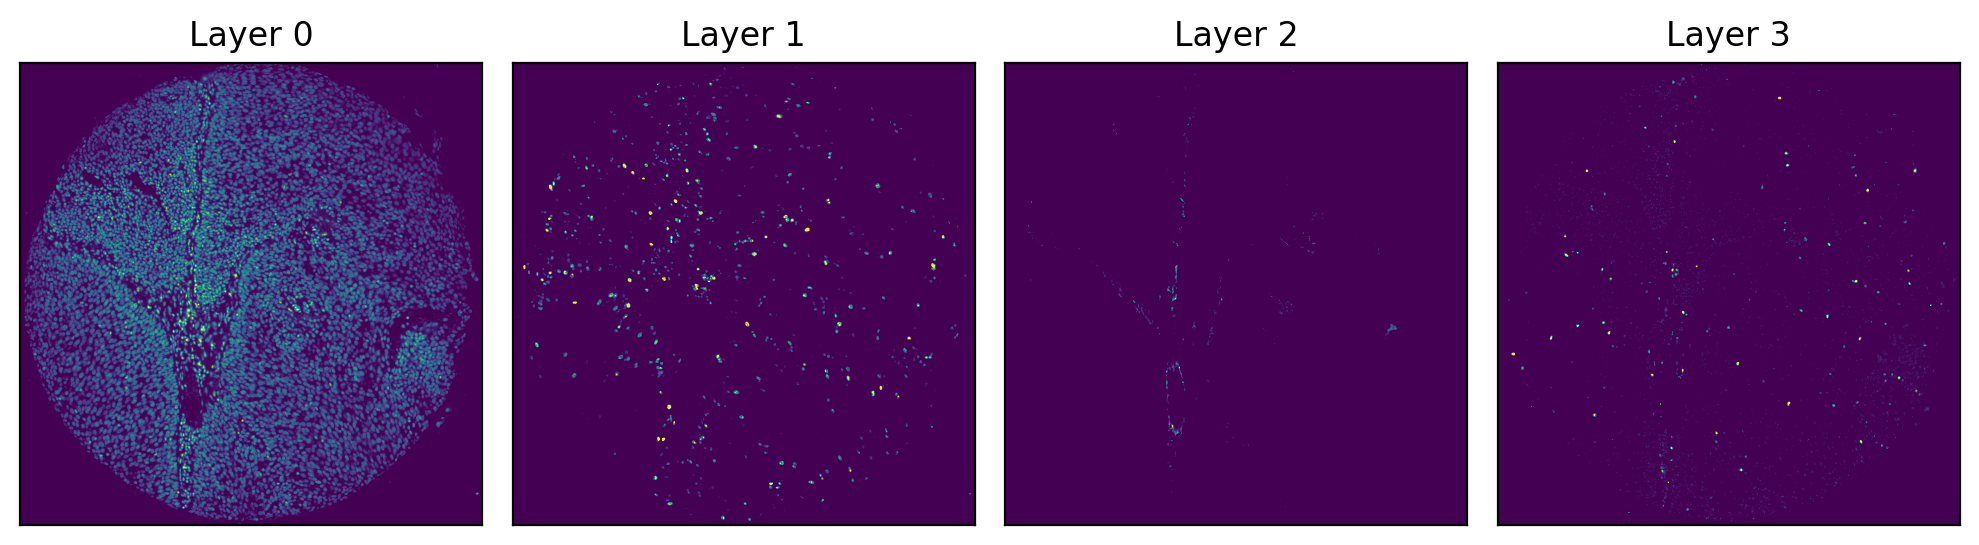

In [10]:
# Example slices of image
n = 4
ranges = [[10, 255], # vmin and vmax of images to be shown
          [5, 80],
          [5, 30],
          [5, 30]]

fig, axes = plt.subplots(1, n, figsize = (n * 2.5, 3)) # Adjust figsize width multiplier (2.5) as needed
for i in range(n):
    ax = axes[i] # Get the specific subplot axis for this layer
    layer_data = core_image[i, :, :]
    im = ax.imshow(layer_data, cmap = 'viridis', vmin = ranges[i][0], vmax = ranges[i][1])

    ax.set_title(f'Layer {i}')
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show(block=False)  # non-blocking
plt.pause(1.0)          # force GUI update

display(fig)


In [13]:
# visualize segmentations:
plot_utils.plot_segmentation(c7_core)

In [12]:
# features of interest (all markers) averaged across entire cell segmentation (Cell_Mean) from Qupath workflow
foi = list(core_exprs.columns[~core_exprs.columns.str.contains('DAPI|orig|Cent|coord|Membr|Nucl|Cyto')])
foi

['Ki67_Cell_Mean',
 'CD31_Cell_Mean',
 'FOXP3_Cell_Mean',
 'CD56_Cell_Mean',
 'CD34_Cell_Mean',
 'CD4_Cell_Mean',
 'CD20_Cell_Mean',
 'CD45_Cell_Mean',
 'CD163_Cell_Mean',
 'HLA.A_Cell_Mean',
 'LAG3_Cell_Mean',
 'CD8_Cell_Mean',
 'SMA_Cell_Mean',
 'PDL1_Cell_Mean',
 'CD21_Cell_Mean',
 'IDO1_Cell_Mean',
 'b.Catenin1_Cell_Mean',
 'CD14_Cell_Mean',
 'PD.1_Cell_Mean',
 'CD44_Cell_Mean',
 'CD3e_Cell_Mean',
 'CD45RO_Cell_Mean',
 'CD68_Cell_Mean',
 'Granzyme.B_Cell_Mean',
 'HLA.DR_Cell_Mean',
 'ICOS_Cell_Mean',
 'HIF1A_Cell_Mean',
 'CK17_Cell_Mean']

Functions for choosing which features to scale, apply for principal components analysis, and clsutering).

Approximate bounds adjusts range of viewing markers for easier annotation when provided through the window, but manual correction is often needed.

In [14]:
for key, core in core_dict.items():
    core.select_features(feats = foi)
    core.run_pca()
    core.run_leiden(resolution = 0.5, random_state = 5) 
    core.run_leiden(resolution = 0.8, random_state = 5)
    core.approximate_bounds()

Running PCA...


Sampling strategies can improve when you more broadly identify cell types of interest. Below I use Immune, stromal, and epithelia lineage markers to define larger lineage level clusters first. This clustering is based on the softmax expression for the markers in 'marker_dict' and kmeans where k is equal to the number of provided lineage markers.

In [15]:
# defining lineage level markers to guide subsclustering steps
marker_dict = {'immune': 'CD45_Cell_Mean', 
               'cd31_stroma':'CD31_Cell_Mean', 
               'sma_stroma':'SMA_Cell_Mean', 
               'epithelia':'Pan.Cytokeratin_Cell_Mean'}

c7_core.lineage_split(marker_dictionary = marker_dict, random_state = 5)

## Kmeans Clustering

In [16]:
# visualizing broad lineage level clustering
plot_utils.cell_plot(core = c7_core, 
                     figsize = (6,4),
                     plot_type = 'PC',
                     col = 'kmeans_lineage', 
                     coloring_type = 'categorical', 
                     size = 3,
                     alpha = 1,
                     palette = 'tab10') #

In [17]:
# plotting softmeax expression on the segmentations itself supports non-overlapping lineages
for marker in list(marker_dict.values()):
    clr = marker.replace('_Cell_Mean', '_softmax')
    plot_utils.cell_plot(c7_core, 
                         plot_type = 'cell', 
                         coloring_type = 'continuous', 
                         col = clr, 
                         figsize = (4,3), 
                         size = 1)

Here we define higher resolutions for immune rich clusters which was based on the kmeans results of lineage level clustering. This function loops into each of the kmeans clusters, rescales the data, and calculates new 'sub' clustering with more specific resolutions. As immune cells were more diverse, I opted for higher clustering resolutions to improve the sampling approach.

In [18]:
resolution_dict = {'0': 0.3, # epithelia
                   '1': 0.5, # immune
                   '2': 0.5, # immune mixed
                   '3': 0.2} # stroma 2

c7_core.run_stratified_clustering(resolution_dict = resolution_dict, 
                                  cluster_method = 'leiden')

## Lieden Clustering

In [19]:
# leiden clustering alone overclusters epithelial cells
plot_utils.cell_plot(core = c7_core, 
                     figsize = (6,4),
                     plot_type = 'PC',
                     col = 'leiden_0.8', 
                     coloring_type = 'categorical', 
                     size = 3,
                     alpha = 1,
                     palette = 'tab20')

## Stratified Clustering

In [20]:
# stratitifed clustering improves resolution of immune cells without inflating epithelial clsuters
plot_utils.cell_plot(core = c7_core, 
                     figsize = (6,4),
                     plot_type = 'PC',
                     col = 'stratified_cluster', 
                     coloring_type = 'categorical', 
                     size = 3,
                     alpha = 1,
                     palette = 'tab20')

Below we use our stratified clsutering strategy to sample diverse cells that will be fed through the annotation window. From these a subset of high quality cells were annotated and used for training our models.  

In [21]:
c7_core.cell_sampler(cluster_col = 'stratified_cluster', 
                     max_sample = 75, 
                     keep_oob = False, 
                     tolerance = 1, 
                     use_fps = True, 
                     random_state = 16)

len(c7_core.sampled_cells)

1159

## Expert Sampling 

In [22]:
# example of what cells were sampled from the cell_sampler function visualized on the first 2 principal componenets
# used to visually support cell sampling comes from a diverse collection of cells

temp_df = c7_core.plot_df.copy()
temp_df.loc[:,'Sampled'] = False
temp_df.loc[c7_core.sampled_cells,'Sampled'] = True

temp_df = temp_df.sort_values('Sampled')

plt.figure(figsize = (4,3))
sns.scatterplot(data = temp_df,  
                x = 'PC1', 
                y = 'PC2', 
                s = 5,
                hue = 'Sampled', 
                palette = ['lightgray', 'red'])

plt.tight_layout()
plt.xticks([])
plt.yticks([])
plt.show()

In [23]:
# these were fine tuned to improve visability of cell types during annotation.
# currently in the core class, a dictionary of each marker exists, with a list where:
# 0th index is what slice of the image contains the specified marker
# 1st index is lower bound of what to visualize (in image)
# 2nd index is upper bound of what to visualize (in image)

c7_core.marker_info['DAPI'] = [0,5,250]
c7_core.marker_info['PanCK'] = [16,0,30]
c7_core.marker_info['CD31'] = [2,0,20]
c7_core.marker_info['SMA'] = [13,0,30]
c7_core.marker_info['CD45'] = [8,5,100]
c7_core.marker_info['CD3e'] = [22,0,20]
c7_core.marker_info['CD4'] = [6,0,20]
c7_core.marker_info['CD8'] = [12,0,30]
c7_core.marker_info['FOXP3'] = [3,5,20]
c7_core.marker_info['CD14'] = [19,0,20]
c7_core.marker_info['CD68'] = [24,3,20]
c7_core.marker_info['CD163'] = [9,0,15]
c7_core.marker_info['HLA-DR'] = [26,0,15]
c7_core.marker_info['CD56'] = [4,2,15]
c7_core.marker_info['CD20'] = [7,2,20]
c7_core.marker_info['CK17'] = [29,0,15]

c7_core.plot_marker(marker = 'PanCK') # adjust manually above and determine appropriate threshold by viewing on whole core

In [25]:
# cell annotations
c7_core.annotate(show_markers = ['DAPI', 'PanCK', 'CD31', 'SMA',
                                 'CD45', 'CD3e', 'CD4', 'CD8', 
                                 'FOXP3', 'CD14', 'CD68', 'CD163',
                                 'HLA-DR', 'CD56', 'CD20', 'CK17'], 
                   cell_types = ['Epi', 'Endothelia', 'Stroma', 
                                 'CD4_T', 'CD8_T','Treg', 'NK', 'Bcell',
                                 'Myeloid','Other_immune', 'Unknown'])

KeyboardInterrupt: 

KeyboardInterrupt: 

In [26]:
# annotations can be saved part way through after quitting the application and saved out / read back in
annotations_dir = os.path.join(root_dir, 'example_data', 'anal_cancer', 'temp_annotations')

# saving out:
# pd.DataFrame.from_dict(c7_core.annotations, orient = 'index').to_csv(os.path.join(annotations_dir, 'C7_annotations.csv'))

# reading in:
result = pd.read_csv(os.path.join(annotations_dir, 'C7_annotations.csv'))
result.columns = ['Object.ID', 'Annotation']
result.value_counts('Annotation') # many more annotated than actually used in training

result = result.set_index('Object.ID')['Annotation'].to_dict()
c7_core.annotations = result 


In [19]:
# multiple annotation files can also be read in, if there are shared cell ids, the later file will override previous annotations
# file_loc = '/path_to_annotatoins/'

# result = annotation_utils.merge_annotations(dfs = [pd.read_csv(file_loc + 'c7_annotations.csv'),
#                                                   pd.read_csv(file_loc + 'c7_annotations2.csv')], 
#                                            exclude_pattern = 'Other|Unknown') # drop cell unwanted annotation types  

# below same as before
result.columns = ['Object.ID', 'Annotation']
result = result.set_index('Object.ID')['Annotation'].to_dict()

c7_core.annotations = result


AttributeError: 'dict' object has no attribute 'columns'

User annotations after annotation were read back in and downsampled to balance classes. This was also used to support the minimum number of cells needed to achieve a good accuracy of cell types in the data. 

In [20]:
np.random.seed(5) # repdroduce sampling
cells_per_class = 40

# Initialize defaultdict with list as the default factory
new_dict = collections.defaultdict(list)

# Group IDs by cell type
for ids, cell_type in result.items():
    new_dict[cell_type].append(ids)  # Append IDs to the appropriate cell type list

# Downsample to n IDs per cell type (or keep all if <n)
downsampled_ids = []
for cell_type, ids in new_dict.items():
    sample_size = min(cells_per_class, len(ids))  # Use 40 or the total available if fewer than n
    selected_ids = np.random.choice(ids, size = sample_size, replace = False)
    downsampled_ids.extend(selected_ids.tolist())

# Create final downsampled dictionary
downsampled_annotations = {ids: c7_core.annotations[ids] for ids in downsampled_ids}

c7_core.annotations = downsampled_annotations

In [22]:
# cells used for all training/validation len(c7_core.annotations.keys())

270

In [21]:
c7_core.plot_df['annotations'] = 'not_annotated' 

# Convert annotations to a list if they aren't
annotations_list = list(c7_core.annotations.values()) #Convert

#Check that keys exist in index before hand!
keys_in_index = [key for key in c7_core.annotations.keys() if key in c7_core.plot_df.index]

# Assign values based on the keys
c7_core.plot_df.loc[keys_in_index, 'annotations'] = annotations_list[:len(keys_in_index)]


In [22]:
# this plots the cells that were annotated by the user back in the original segmentation data
plot_utils.cell_plot(core = c7_core, 
                     figsize = (6,4),
                     plot_type = 'cell', 
                     col = 'annotations', 
                     size = 4, 
                     coloring_type = 'categorical', 
                     palette = 'tab20')

When samples have been annotated, the core class is handed off to a new python class that handles model training, prediction, and cross validation. Options for different models include the use of imbalanced random forests which handle sampling of minority classes differently and the use of SMOTE, which generates synthetic minority classes in an attempt to better define features that identify those.

In [23]:
my_classifier = classifier_class.classify_cells(core_class = c7_core)

rf_feats = c7_core.expression_data.columns[c7_core.expression_data.columns.str.contains('Cell_Mean')]

In [24]:
cv = my_classifier.k_fold_cross_validation(use_params = rf_feats, 
                                           n_splits = 5, 
                                           random_state = 15, 
                                           use_imbalanced_rf = True, 
                                           use_smote = True, 
                                           n_trees = 200)

cv

C:\Users\evanj\anaconda3\Lib\site-packages\imblearn\ensemble\_forest.py:577: FutureWarning: The default of `sampling_strategy` will change from `'auto'` to `'all'` in version 0.13. This change will follow the implementation proposed in the original paper. Set to `'all'` to silence this warning and adopt the future behaviour.
  warn(
C:\Users\evanj\anaconda3\Lib\site-packages\imblearn\ensemble\_forest.py:589: FutureWarning: The default of `replacement` will change from `False` to `True` in version 0.13. This change will follow the implementation proposed in the original paper. Set to `True` to silence this warning and adopt the future behaviour.
  warn(
C:\Users\evanj\anaconda3\Lib\site-packages\imblearn\ensemble\_forest.py:601: FutureWarning: The default of `bootstrap` will change from `True` to `False` in version 0.13. This change will follow the implementation proposed in the original paper. Set to `False` to silence this warning and adopt the future behaviour.
  warn(
C:\Users\evanj

,fold,class,f1,precision,recall,accuracy
0,1,CD4_T,0.823529,0.777778,0.875000,0.925926
1,1,CD8_T,1.000000,1.000000,1.000000,0.925926
2,1,Endothelia,1.000000,1.000000,1.000000,0.925926
3,1,Epi,0.933333,1.000000,0.875000,0.925926
4,1,Myeloid,0.941176,0.888889,1.000000,0.925926
5,1,Stroma,0.857143,1.000000,0.750000,0.925926
6,1,Treg,0.923077,0.857143,1.000000,0.925926
7,2,CD4_T,0.888889,0.800000,1.000000,0.870370
8,2,CD8_T,1.000000,1.000000,1.000000,0.870370
9,2,Endothelia,0.823529,0.777778,0.875000,0.870370


In [25]:
print(np.mean(cv['accuracy'])) # 90.4% accuracy
print(np.std(cv['accuracy'])) # 2.7% sd

0.8962962962962961
0.04771888417305604


In [26]:
plot_utils.plot_metrics(cv, metrics = ['recall', 'precision', 'f1'])

In [27]:
# full model for classification
my_classifier.train(split = None, 
                    use_params = rf_feats, 
                    random_state = 19, 
                    use_imbalanced_rf = True, 
                    use_smote = True)
my_classifier.fit()


Class Counts after filtering classes with < 2 samples:
annotations
Myeloid       40
Stroma        40
Epi           40
CD4_T         40
Endothelia    40
CD8_T         40
Treg          30
Name: count, dtype: int64

Class counts in y_train after train_test_split:
annotations
Myeloid       40
Stroma        40
Epi           40
CD4_T         40
Endothelia    40
CD8_T         40
Treg          30
Name: count, dtype: int64

Class counts in y_test after train_test_split:
Series([], Name: count, dtype: int64)
min class count 30

applying smote to full *training* set with knn=5

Class counts in y_train after smote:
annotations
Myeloid       40
Stroma        40
Epi           40
CD4_T         40
Endothelia    40
Treg          40
CD8_T         40
Name: count, dtype: int64


C:\Users\evanj\anaconda3\Lib\site-packages\imblearn\ensemble\_forest.py:577: FutureWarning: The default of `sampling_strategy` will change from `'auto'` to `'all'` in version 0.13. This change will follow the implementation proposed in the original paper. Set to `'all'` to silence this warning and adopt the future behaviour.
  warn(
C:\Users\evanj\anaconda3\Lib\site-packages\imblearn\ensemble\_forest.py:589: FutureWarning: The default of `replacement` will change from `False` to `True` in version 0.13. This change will follow the implementation proposed in the original paper. Set to `True` to silence this warning and adopt the future behaviour.
  warn(
C:\Users\evanj\anaconda3\Lib\site-packages\imblearn\ensemble\_forest.py:601: FutureWarning: The default of `bootstrap` will change from `True` to `False` in version 0.13. This change will follow the implementation proposed in the original paper. Set to `False` to silence this warning and adopt the future behaviour.
  warn(


In [28]:
my_classifier.plot_data['prediction'] = ''
c7_core.plot_df.loc[my_classifier.expression_data.index, 'prediction'] = my_classifier.expression_data['predicted_annotation']

In [29]:
display(c7_core)

In [30]:
plot_utils.cell_plot(core = c7_core, 
                     plot_type = 'cell', 
                     figsize = (6,4),
                     coloring_type = 'categorical', 
                     palette = 'tab20', 
                     size = 1tion').5,
                     col = 'predic

display(c7_core)

SyntaxError: invalid decimal literal (129947487.py, line 6)

In [ ]:
plot_utils.contingency_plot(core = c7_core, 
                            column1 = 'leiden_0.8',
                            column2 = 'prediction')

In [ ]:
plot_utils.expression_heatmap(core = c7_core, 
                              cluster_col = 'leiden_0.8', 
                              cell_mean_substring = 'Cell_Mean', 
                              cmap = 'vlag', 
                              figsize = (4,6))

Higher clustering resolutions were applied to see if Tregs and CD4+ T cells could be separated. Leiden unable to do on its own. 

In [ ]:
core.run_leiden(resolution = 1.0, random_state = 5)

plot_utils.expression_heatmap(core = c7_core, 
                              cluster_col = 'leiden_1.0', 
                              cell_mean_substring = 'Cell_Mean', 
                              cmap = 'vlag', 
                              figsize = (4,6))

In [ ]:
plot_utils.expression_heatmap(core = c7_core, 
                              cluster_col = 'prediction', 
                              cell_mean_substring = 'Cell_Mean', 
                              cmap = 'vlag', 
                              figsize = (4,6))

In [31]:
my_classifier.expression_data['annotations'].value_counts()
my_classifier.expression_data['predicted_annotation'].value_counts()

predicted_annotation
Epi           8153
Myeloid        353
Endothelia     252
Stroma         236
CD8_T          213
CD4_T          137
Treg            71
Name: count, dtype: int64

In [32]:
# Used in figure 1C (2 fold cross validation)
my_classifier = classifier_class.classify_cells(core_class = c7_core)
my_classifier.train(split = 0.5, # half train half test 
                    use_params = rf_feats, 
                    random_state = 19, 
                    use_imbalanced_rf = False)
my_classifier.fit()



Class Counts after filtering classes with < 2 samples:
annotations
Myeloid       40
Stroma        40
Epi           40
CD4_T         40
Endothelia    40
CD8_T         40
Treg          30
Name: count, dtype: int64

Class counts in y_train after train_test_split:
annotations
CD4_T         20
CD8_T         20
Endothelia    20
Epi           20
Myeloid       20
Stroma        20
Treg          15
Name: count, dtype: int64

Class counts in y_test after train_test_split:
annotations
CD4_T         20
CD8_T         20
Endothelia    20
Epi           20
Myeloid       20
Stroma        20
Treg          15
Name: count, dtype: int64
model Accuracy: 0.87

Classification Report:
              precision    recall  f1-score   support

       CD4_T       0.82      0.70      0.76        20
       CD8_T       0.91      1.00      0.95        20
  Endothelia       0.86      0.90      0.88        20
         Epi       0.81      0.85      0.83        20
     Myeloid       0.95      0.95      0.95        20
      

In [33]:
df = my_classifier.expression_data.loc[:,['annotations', 'predicted_annotation']]
df.loc[:,'leiden_0.8'] = my_classifier.plot_data['leiden_0.8']
df = df.loc[df['annotations'] != '', :]
df = df.loc[my_classifier.plot_data['used_in_training'] == False,:]

In [34]:
plot_utils.contingency_plot(core = None, 
                            column1 = df['annotations'], 
                            column2 = df['predicted_annotation'], 
                           figsize = (3.5,3))

In [35]:
plot_utils.contingency_plot(core = None, 
                            column1 = df['annotations'], 
                            column2 = df['leiden_0.8'], 
                           figsize = (3.5,3))

In [36]:
plot_utils.expression_heatmap(core = c7_core, 
                              cluster_col = 'leiden_0.8', 
                              cell_mean_substring = 'Cell_Mean', 
                              cmap = 'vlag', 
                              figsize = (4,6))

In [37]:
#leiden mapping (0.8)
expression_key = {'0': 'epi', '1':'epi', '2':'epi', '3':'epi', 
                  '4':'epi', '5':'stroma', '6':'Myeloid', '7':'other',
                  '8':'other', '9':'CD8_T', '10':'epi', '11':'CD4_T/Treg', 
                  '12':'other'}

In [38]:
converted = df['leiden_0.8'].map(expression_key)
df.loc[:,'leiden_key'] = converted
plot_utils.contingency_plot(core = None, 
                            column1 = df['annotations'], 
                            column2 = df['leiden_key'],
                           figsize = (3.5,3))

In [39]:
# full model prediction
my_classifier.plot_data['prediction'] = ''
my_classifier.train(split = None, 
                    use_params = rf_feats, 
                    random_state = 19, 
                    use_imbalanced_rf = True, 
                    use_smote = True)

my_classifier.fit()
c7_core.plot_df.loc[my_classifier.expression_data.index, 'prediction'] = my_classifier.expression_data['predicted_annotation']

c7_core.plot_df.loc[:,'prediction'].value_counts()


Class Counts after filtering classes with < 2 samples:
annotations
Myeloid       40
Stroma        40
Epi           40
CD4_T         40
Endothelia    40
CD8_T         40
Treg          30
Name: count, dtype: int64

Class counts in y_train after train_test_split:
annotations
Myeloid       40
Stroma        40
Epi           40
CD4_T         40
Endothelia    40
CD8_T         40
Treg          30
Name: count, dtype: int64

Class counts in y_test after train_test_split:
Series([], Name: count, dtype: int64)
min class count 30

applying smote to full *training* set with knn=5

Class counts in y_train after smote:
annotations
Myeloid       40
Stroma        40
Epi           40
CD4_T         40
Endothelia    40
Treg          40
CD8_T         40
Name: count, dtype: int64


C:\Users\evanj\anaconda3\Lib\site-packages\imblearn\ensemble\_forest.py:577: FutureWarning: The default of `sampling_strategy` will change from `'auto'` to `'all'` in version 0.13. This change will follow the implementation proposed in the original paper. Set to `'all'` to silence this warning and adopt the future behaviour.
  warn(
C:\Users\evanj\anaconda3\Lib\site-packages\imblearn\ensemble\_forest.py:589: FutureWarning: The default of `replacement` will change from `False` to `True` in version 0.13. This change will follow the implementation proposed in the original paper. Set to `True` to silence this warning and adopt the future behaviour.
  warn(
C:\Users\evanj\anaconda3\Lib\site-packages\imblearn\ensemble\_forest.py:601: FutureWarning: The default of `bootstrap` will change from `True` to `False` in version 0.13. This change will follow the implementation proposed in the original paper. Set to `False` to silence this warning and adopt the future behaviour.
  warn(


prediction
Epi           8153
Myeloid        353
Endothelia     252
Stroma         236
CD8_T          213
CD4_T          137
Treg            71
Name: count, dtype: int64

In [40]:
# for consistent plotting when there are multiple 
my_pal = sns.color_palette('tab20').as_hex()

cmap = {'not_annotated':'gray', 'Epi':my_pal[0], 
        'Myeloid': my_pal[1], 'Endothelia':my_pal[2],
        'Stroma':my_pal[3], 'CD8_T':my_pal[4],
        'CD4_T':my_pal[5], 'Treg':my_pal[6]}

In [41]:
for i,clst in enumerate(np.unique(df['leiden_0.8'])):
    cmap[str(clst)] = my_pal[i+7] # 7 is offset for number used in past cmap

In [42]:
sankey(df['annotations'], 
       df['leiden_0.8'], 
       aspect = 5, fontsize = 10,
       colorDict = cmap, 
       rightColor = False)
plt.tight_layout()
plt.show()

NameError: name 'sankey' is not defined

In [43]:
plot_utils.cell_plot(core = c7_core, 
                     color_map = cmap,
                     plot_type = 'cell', 
                     figsize = (6,4),
                     coloring_type = 'categorical', 
                     palette = 'tab20', 
                     size = 1,
                     col = 'prediction')

## Core to Anndata Object Conversion

In [54]:
display(X)

NameError: name 'X' is not defined

In [66]:
import anndata as ad
import pandas as pd
import numpy as np

def core_to_anndata(core) -> ad.AnnData:
    # features (exclude coords)
    expr_cols = [c for c in core.expression_data.columns if c not in ['X_coord', 'Y_coord']]
    X = core.expression_data[expr_cols]#.select_dtypes(include=[np.number]).values
    #display(X)

    # obs
    obs = core.plot_df.reindex(core.expression_data.index).copy()
    obs.index = core.expression_data.index.astype(str)

    # var
    var = pd.DataFrame(index=expr_cols)
    if isinstance(core.marker_info, dict):
        for col in expr_cols:
            if col in core.marker_info:
                var.loc[col, :] = core.marker_info[col]

    adata = ad.AnnData(X=X, obs=obs, var=var)

    # obsm
    if len(core.pc_data) > 0:
        adata.obsm['X_pca'] = core.pc_data
    if {'X_coord','Y_coord'}.issubset(core.expression_data.columns):
        adata.obsm['spatial'] = core.expression_data[['X_coord','Y_coord']].values

    # uns
    adata.uns['manual_samples'] = dict(core.manual_samples)
    adata.uns['lineage_info'] = {
        "assignments": core.lineage_assignments.to_dict() if hasattr(core.lineage_assignments, 'to_dict') else {},
        "subsets": core.lineage_subsets,
        "softmax": core.lineage_softmax.to_dict() if hasattr(core.lineage_softmax, 'to_dict') else {},
        "subclusters": core.subclusters,
    }
    adata.uns['image'] = np.array(core.image) if core.image is not None else None
    adata.uns['segments'] = dict(core.segments) if core.segments else {}


    return adata


# Convert core 7 into an AnnData object
adata_core7 = core_to_anndata(c7_core)
display(adata_core7.X)

#display(adata_core7.obs.tail(50))

array([[6.21852933, 0.62077407, 2.24360816, ..., 0.16530097, 1.33136127,
        0.54833798],
       [6.29001885, 0.9068906 , 2.43741419, ..., 0.2767944 , 1.19440229,
        1.06108492],
       [6.71424552, 3.91691607, 2.49415956, ..., 0.31034012, 0.90819805,
        0.67807191],
       ...,
       [7.03214714, 0.89367285, 2.49758682, ..., 0.26303441, 1.15827239,
        1.78751605],
       [6.97487687, 0.64071346, 2.65188979, ..., 0.32573179, 1.21207124,
        0.8292001 ],
       [6.24205749, 0.77904955, 2.53256632, ..., 0.21884315, 0.93462972,
        0.49610438]])

## Save Anndata Object for Off-Site Loading

In [61]:
display(adata_core7.X)

array([[6.21852933, 0.62077407, 2.24360816, ..., 0.16530097, 1.33136127,
        0.54833798],
       [6.29001885, 0.9068906 , 2.43741419, ..., 0.2767944 , 1.19440229,
        1.06108492],
       [6.71424552, 3.91691607, 2.49415956, ..., 0.31034012, 0.90819805,
        0.67807191],
       ...,
       [7.03214714, 0.89367285, 2.49758682, ..., 0.26303441, 1.15827239,
        1.78751605],
       [6.97487687, 0.64071346, 2.65188979, ..., 0.32573179, 1.21207124,
        0.8292001 ],
       [6.24205749, 0.77904955, 2.53256632, ..., 0.21884315, 0.93462972,
        0.49610438]])

In [62]:
# --- Save AnnData object ---
adata_core7 = core_to_anndata(c7_core)   # convert your core object
adata_core7.write("core7_anndata.h5ad")  # save to disk
print("Saved AnnData object to core7_anndata.h5ad")

# # --- Load AnnData object ---
# adata_loaded = ad.read_h5ad("core7_anndata.h5ad")
# print("Loaded AnnData object with shape:", adata_loaded.shape)

Saved AnnData object to core7_anndata.h5ad
